In [2]:
#%%pip install geopandas
#%%pip install rasterio
#%%pip install matplotlib
#%%pip install rasterstats

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.merge import merge
from rasterstats import zonal_stats
from rasterio.mask import mask
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches

# Reusable framework code (installed via `pip install -e .` from the repo root)
from sdframework import config as sdconfig
from sdframework.io import load_basin_data

In [ ]:
# Configuration (paths resolved by sdframework.config; keeps the original
# `config[...]` keys so the rest of the notebook is unchanged)
config = {
    'shapefile': sdconfig.input_data('shapefiles', 'Alberta', 'HydrologicUnitCode6WatershedsOfAlberta.shp'),
    'tif_files': sdconfig.input_data('shapefiles', 'tif'),
    'output_dir': sdconfig.output_data('elevation'),
    'output_plots': sdconfig.output_plots('elevation'),
}

In [6]:
# 1. Load Shapefile ===
gdf = load_basin_data(config['shapefile'])
display(gdf.head)

<bound method NDFrame.head of       HUC_6 HUC_4 HUC_2 WSC_CODE                             NAME  \
0    020201  0202    02     11AB          MILK RIVER - SAGE CREEK   
1    040104  0401    04     05AE                   ST. MARY RIVER   
2    020101  0201    02     05AF    ETZIKOM COULEE - PAKOWKI LAKE   
3    020202  0202    02     11AB       MIDDLE CREEK - LODGE CREEK   
4    040103  0401    04     05AD                   WATERTON RIVER   
..      ...   ...   ...      ...                              ...   
127  220101  2201    22     07UC                     KAKISA RIVER   
128  230102  2301    23     07PB             LITTLE BUFFALO RIVER   
129  240102  2401    24     07NB  MIDDLE SLAVE RIVER - SALT RIVER   
130  250101  2501    25     07QA       ANDREW LAKE - TETHUL RIVER   
131  250103  2501    25     07QC                    TALTSON RIVER   

       SHAPE_STAr     SHAPE_STLe  \
0    5.482824e+09  724429.096837   
1    2.567038e+09  293678.132517   
2    5.054952e+09  659023.544215 

In [7]:
# 2. Merge the TIFs ===
src_files_to_mosaic = [rasterio.open(fp) for fp in glob.glob(str(config['tif_files']) + "/*.tif")]
mosaic, out_transform = merge(src_files_to_mosaic)

In [11]:
# 3. Write the Merged Raster to Disk ===
mosaic_meta = src_files_to_mosaic[0].meta.copy()
mosaic_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_transform
})

merged_tif_path = config['output_dir'] / "merged_dem.tif"
with rasterio.open(merged_tif_path, "w", **mosaic_meta) as dest:
    dest.write(mosaic)

In [12]:
# 4. Compute Zonal Statistics ===
# reproject vector to raster CRS before zonal_stats to avoid huge rasterization
with rasterio.open(merged_tif_path) as src:
    raster_crs = src.crs

gdf_proj = gdf.to_crs(raster_crs)

stats = zonal_stats(
    gdf_proj,
    merged_tif_path,
    stats=["min", "max", "mean", "std", "median", "count"],
    nodata=mosaic_meta.get('nodata', None),
    geojson_out=True
)

c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\Snow_Drought_Framework\.venv-1\Lib\site-packages\rasterstats\io.py:437: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


In [14]:
# 5. Create GeoDataFrame with Stats ===
stats_gdf = gpd.GeoDataFrame.from_features(stats)

In [15]:
# 6. Save to New Shapefile or CSV ===
output_shapefile_path = os.path.join(config['output_dir'], "Alberta_elevation_with_stats.shp")
output_dir = os.path.dirname(output_shapefile_path)
output_csv_path = os.path.join(output_dir, "Alberta_stats.csv")

# save the GeoDataFrame to a shapefile
#stats_gdf.to_file(output_shapefile_path)
#stats_gdf.drop(columns="geometry").to_csv(output_csv_path, index=False)  # Also save as CSV

print("✅ Elevation statistics extracted and saved.")

✅ Elevation statistics extracted and saved.


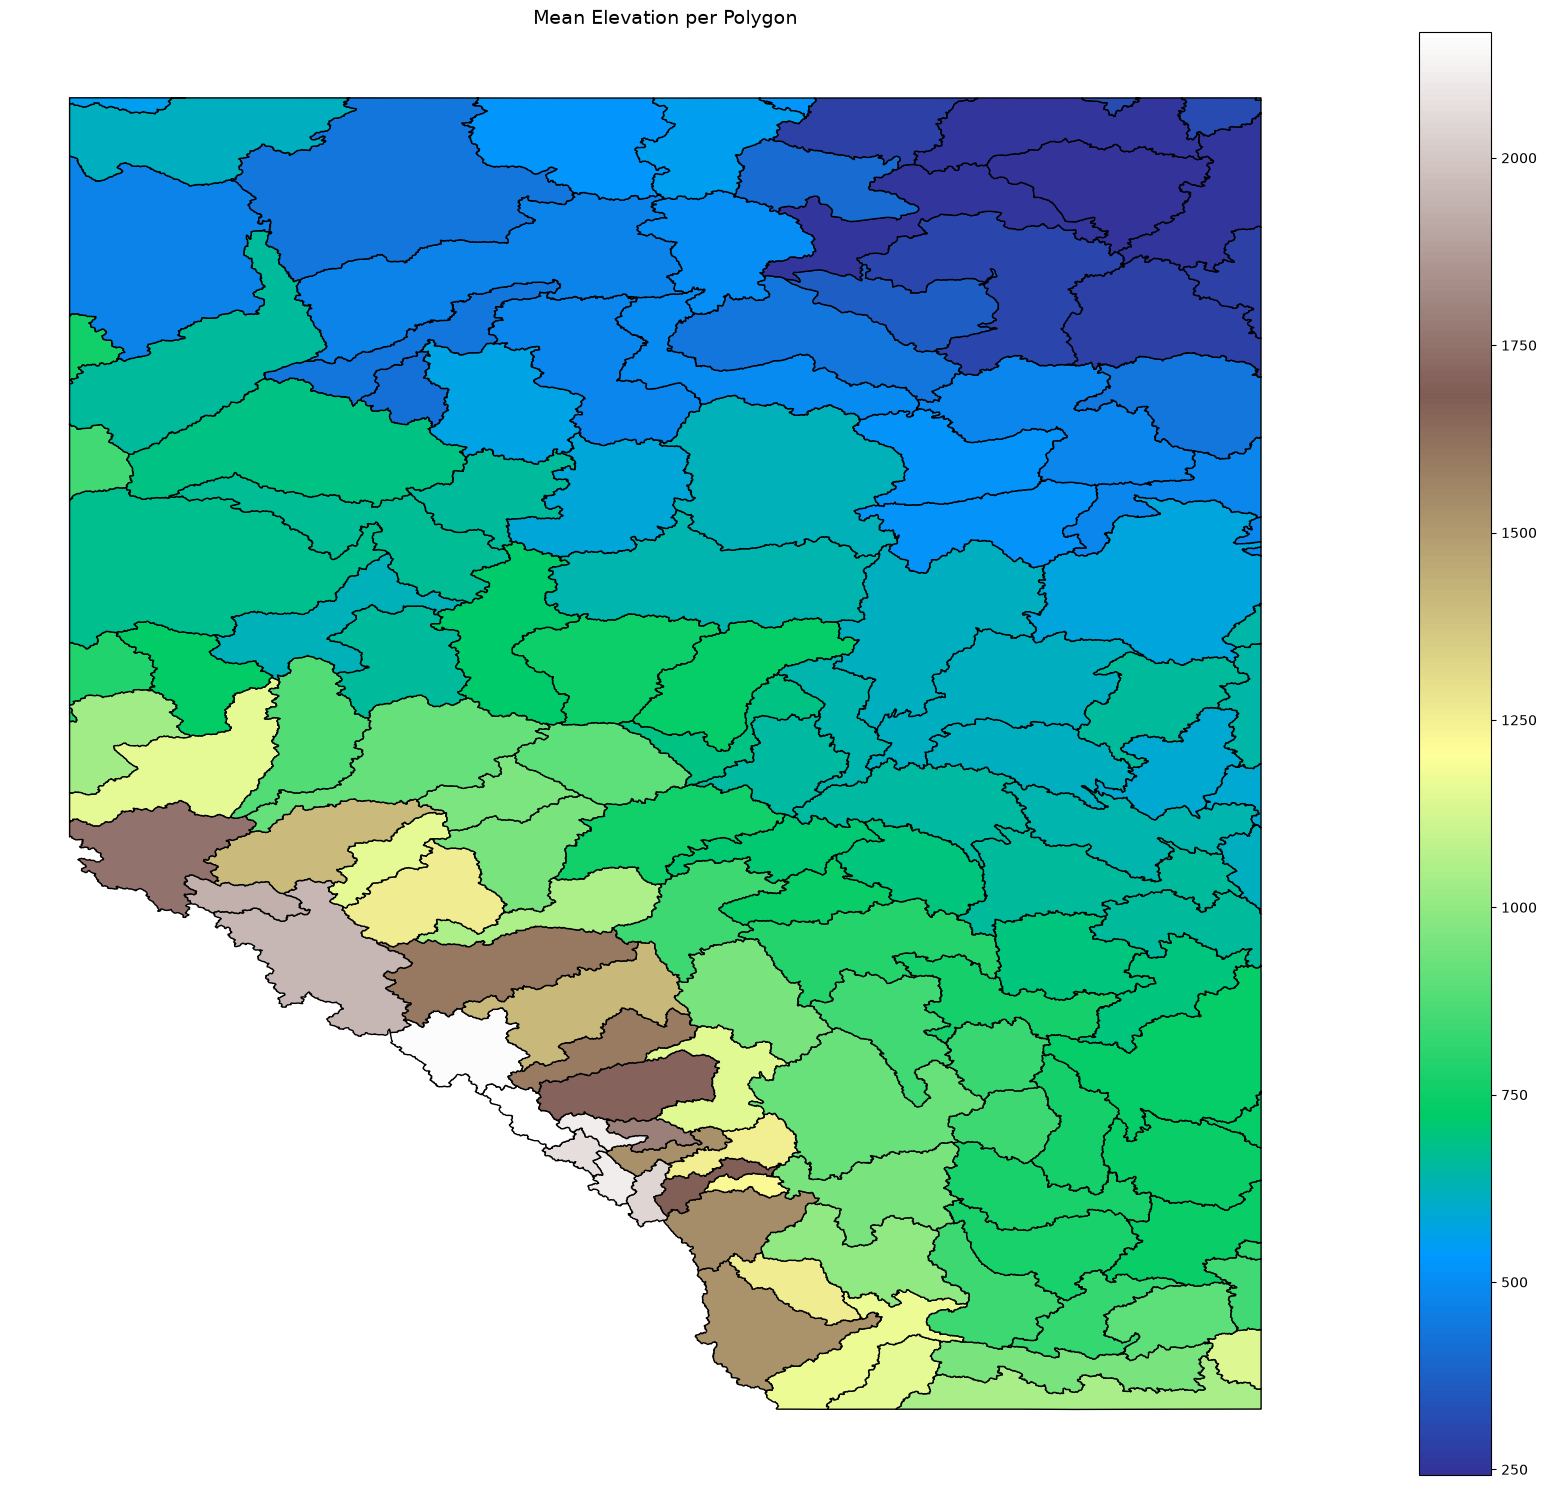

In [25]:
# Load shapefile with elevation stats
gdf = gpd.read_file(output_shapefile_path)  # or your output file

# Plot mean elevation
fig, ax = plt.subplots(figsize=(20, 15))
gdf.plot(column='mean', cmap='terrain', legend=True, edgecolor='black', ax=ax)

ax.set_title("Mean Elevation per Polygon", fontsize=14)
ax.axis('off')
plt.tight_layout()
# Save the plot
plt.savefig(os.path.join(config['output_plots'], "mean_elevation_plot.png"), dpi=300)
plt.show()

In [21]:
# Clip the merged DEM using the geometry from the shapefile
with rasterio.open(merged_tif_path) as src:
    shapes = list(gdf_proj.geometry)
    clipped_dem, clipped_transform = mask(src, shapes=shapes, crop=True)


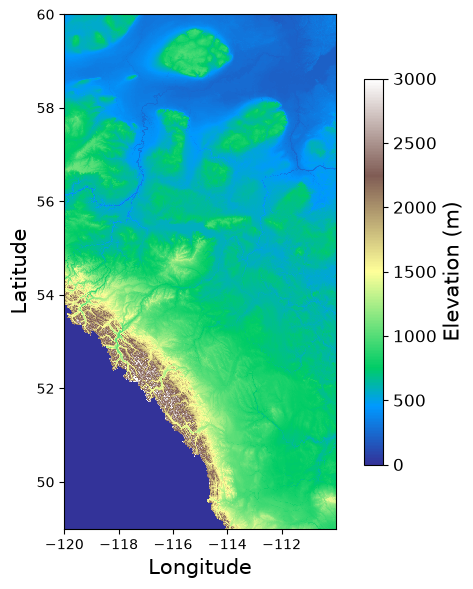

In [26]:
# Mask nodata using mosaic_meta or assume 0 is nodata if not set
nodata_value = mosaic_meta.get("nodata", 0)

extent = [
    clipped_transform.c,
    clipped_transform.c + clipped_dem.shape[2] * clipped_transform.a,
    clipped_transform.f + clipped_dem.shape[1] * clipped_transform.e,
    clipped_transform.f,
]

mean_lat = (extent[2] + extent[3]) / 2
aspect = 1 / np.cos(np.deg2rad(mean_lat))

# Downsample the raster for plotting so Matplotlib does not allocate a full-resolution RGBA buffer.
max_display_pixels = 2000
step = max(1, int(np.ceil(max(clipped_dem.shape[1], clipped_dem.shape[2]) / max_display_pixels)))
plot_band = clipped_dem[0][::step, ::step]
plot_data = np.where(plot_band == nodata_value, np.nan, plot_band)

fig, ax = plt.subplots(figsize=(15, 6))

im = ax.imshow(
    plot_data,
    cmap="terrain",
    vmin=0,
    vmax=3000,
    extent=extent,
    interpolation="nearest",
)

ax.set_aspect(aspect)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    pad=0.02,
    fraction=0.03,
    shrink=0.75,
)

cbar.ax.tick_params(labelsize=12)
cbar.set_label("Elevation (m)", fontsize=15)

ax.set_xlabel("Longitude", fontsize=15)
ax.set_ylabel("Latitude", fontsize=15)

plt.tight_layout()
# Save the current figure as a PNG file in the output_path directory
os.makedirs(config['output_plots'], exist_ok=True)
save_path = os.path.join(config['output_plots'], 'clipped_elevation_map.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()


In [35]:
# Split polygons into elevation classes and save separate shapefiles

# Define elevation bins (adjust as needed)
elevation_bins = [0, 500, 1000, 1500, 2000,2500, 3000]
elevation_labels = [f"{elevation_bins[i]}_{elevation_bins[i+1]}m" for i in range(len(elevation_bins)-1)]

# Ensure 'mean' column exists in stats_gdf
if 'mean' in stats_gdf.columns:
    stats_gdf['elev_class'] = pd.cut(stats_gdf['mean'], bins=elevation_bins, labels=elevation_labels, include_lowest=True)
    # Convert to string for shapefile output
    stats_gdf['elev_class'] = stats_gdf['elev_class'].astype(str)
    stats_gdf = stats_gdf.set_crs("EPSG:4326")
    for label in elevation_labels:
        subset = stats_gdf[stats_gdf['elev_class'] == str(label)]
        if not subset.empty:
            out_path = os.path.join(output_dir, f"Alberta_elevation_{label}.shp")
            subset.to_file(out_path)
            print(f"Saved: {out_path}")
else:
    print("Column 'mean' not found in stats_gdf.")

Saved: c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\Snow_Drought_Framework\Data\output_data\elevation\Alberta_elevation_0_500m.shp
Saved: c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\Snow_Drought_Framework\Data\output_data\elevation\Alberta_elevation_500_1000m.shp
Saved: c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\Snow_Drought_Framework\Data\output_data\elevation\Alberta_elevation_1000_1500m.shp
Saved: c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\Snow_Drought_Framework\Data\output_data\elevation\Alberta_elevation_1500_2000m.shp
Saved: c:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\Snow_Drought_Framework\Data\output_data\elevation\Alberta_elevation_2000_2500m.shp


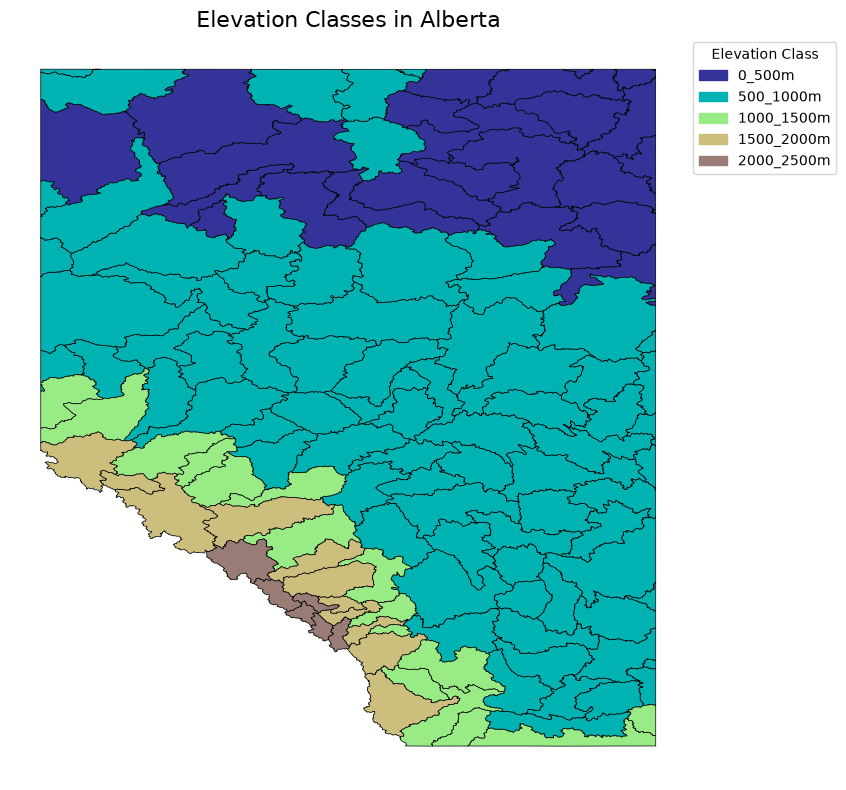

In [29]:
# Plot all elevation class shapefiles in one plot

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.terrain(np.linspace(0, 1, len(elevation_labels)))
legend_handles = []

for i, label in enumerate(elevation_labels):
    shp_path = os.path.join(output_dir, f"Alberta_elevation_{label}.shp")
    if os.path.exists(shp_path):
        class_gdf = gpd.read_file(shp_path)
        class_gdf.plot(ax=ax, color=colors[i], label=label, edgecolor='black', linewidth=0.5)
        legend_handles.append(mpatches.Patch(color=colors[i], label=label))

ax.set_title("Elevation Classes in Alberta", fontsize=16)
ax.axis('off')
ax.legend(handles=legend_handles,title="Elevation Class", loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(os.path.join(config['output_plots'], 'Elevation_map.png'), dpi=300, bbox_inches='tight')
plt.show()


In [33]:
# join all elevation class shapefiles into one shapefile
all_classes = []
for label in elevation_labels:
    # join all elevation class shapefiles into one shapefile
    all_classes = []

    for label in elevation_labels:
        shp_path = os.path.join(config['output_dir'], f"Alberta_elevation_{label}.shp")
        if os.path.exists(shp_path):
            class_gdf = gpd.read_file(shp_path)
            all_classes.append(class_gdf)

    if all_classes:
        combined_gdf = gpd.GeoDataFrame(pd.concat(all_classes, ignore_index=True))
        combined_gdf = combined_gdf.set_crs("EPSG:4326")
        combined_gdf.to_file(os.path.join(config['output_dir'], "Alberta_elevation_combined.shp"))
        print("Combined shapefile saved as Alberta_elevation_combined.shp")
    else:
        print("No elevation class shapefiles found to combine.")
    if os.path.exists(shp_path):
        class_gdf = gpd.read_file(shp_path)
        all_classes.append(class_gdf)
        if all_classes:
            combined_gdf = gpd.GeoDataFrame(pd.concat(all_classes, ignore_index=True))
            combined_gdf = combined_gdf.set_crs("EPSG:4326")
            combined_gdf.to_file(os.path.join(config['output_data'], "Alberta_elevation_combined.shp"))
            print("Combined shapefile saved as Alberta_elevation_combined.shp")

Combined shapefile saved as Alberta_elevation_combined.shp
Combined shapefile saved as Alberta_elevation_combined.shp
Combined shapefile saved as Alberta_elevation_combined.shp
Combined shapefile saved as Alberta_elevation_combined.shp
Combined shapefile saved as Alberta_elevation_combined.shp
Combined shapefile saved as Alberta_elevation_combined.shp


In [34]:
print(combined_gdf.crs)

EPSG:4326
